In [3]:
# Import required libraries
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import joblib  # For saving/loading model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tqdm import tqdm
import random

In [4]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# Define dataset paths
dataset_path = "/content/drive/MyDrive/TCV BANANA/Real Dataset/Final"
own_dataset_path = "/content/drive/MyDrive/TCV BANANA/Real Dataset/Preprocessed/Own"  # New dataset for testing generalization
categories = ["Ripe", "Unripe", "Semiripe", "Overripe-Rotten"]

In [6]:
# Function to extract Color Histogram features
def extract_color_histogram(image, bins=(8, 8, 8)):
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)  # Convert to HSV color space
    hist = cv2.calcHist([hsv], [0, 1, 2], None, bins, [0, 180, 0, 256, 0, 256])
    cv2.normalize(hist, hist)  # Normalize histogram
    return hist.flatten()

In [7]:
# Function to load dataset
def load_dataset(base_path):
    data = []
    labels = []
    image_paths = []

    for category in categories:
        folder_path = os.path.join(base_path, category)
        label = category

        if not os.path.exists(folder_path):
            print(f"Folder not found: {folder_path}")
            continue

        for img_name in tqdm(os.listdir(folder_path), desc=f"Loading {category}"):
            img_path = os.path.join(folder_path, img_name)

            # Read image in RGB format
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (224, 224))  # Keep uniform size

            # Extract Color Histogram Features
            features = extract_color_histogram(img)

            data.append(features)
            labels.append(label)
            image_paths.append(img_path)  # Store image path for visualization

    data = np.array(data, dtype=np.float32)
    labels = np.array(labels)

    return data, labels, image_paths


In [8]:
# Load Training Dataset
print("\nLoading Training Dataset...")
data, labels, image_paths = load_dataset(dataset_path)


Loading Training Dataset...


Loading Overripe-Rotten: 100%|██████████| 350/350 [00:07<00:00, 44.40it/s]


In [9]:
# Show total images loaded
print(f"Total training images loaded: {len(data)}")

Total training images loaded: 1400


In [10]:
# Encode labels (Convert category names to numerical labels)
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)

In [11]:
# ---- CHECK LABEL ENCODING ----
print("\nChecking Label Encoding...")
label_df = pd.DataFrame({"Original Label": labels, "Encoded Label": encoded_labels})
print(label_df.head(10))  # Display first 10 label mappings

# Print unique label encoding mapping
print("\nLabel Encoding Mapping:")
for label, encoded in zip(label_encoder.classes_, range(len(label_encoder.classes_))):
    print(f"{label} -> {encoded}")


Checking Label Encoding...
  Original Label  Encoded Label
0           Ripe              1
1           Ripe              1
2           Ripe              1
3           Ripe              1
4           Ripe              1
5           Ripe              1
6           Ripe              1
7           Ripe              1
8           Ripe              1
9           Ripe              1

Label Encoding Mapping:
Overripe-Rotten -> 0
Ripe -> 1
Semiripe -> 2
Unripe -> 3


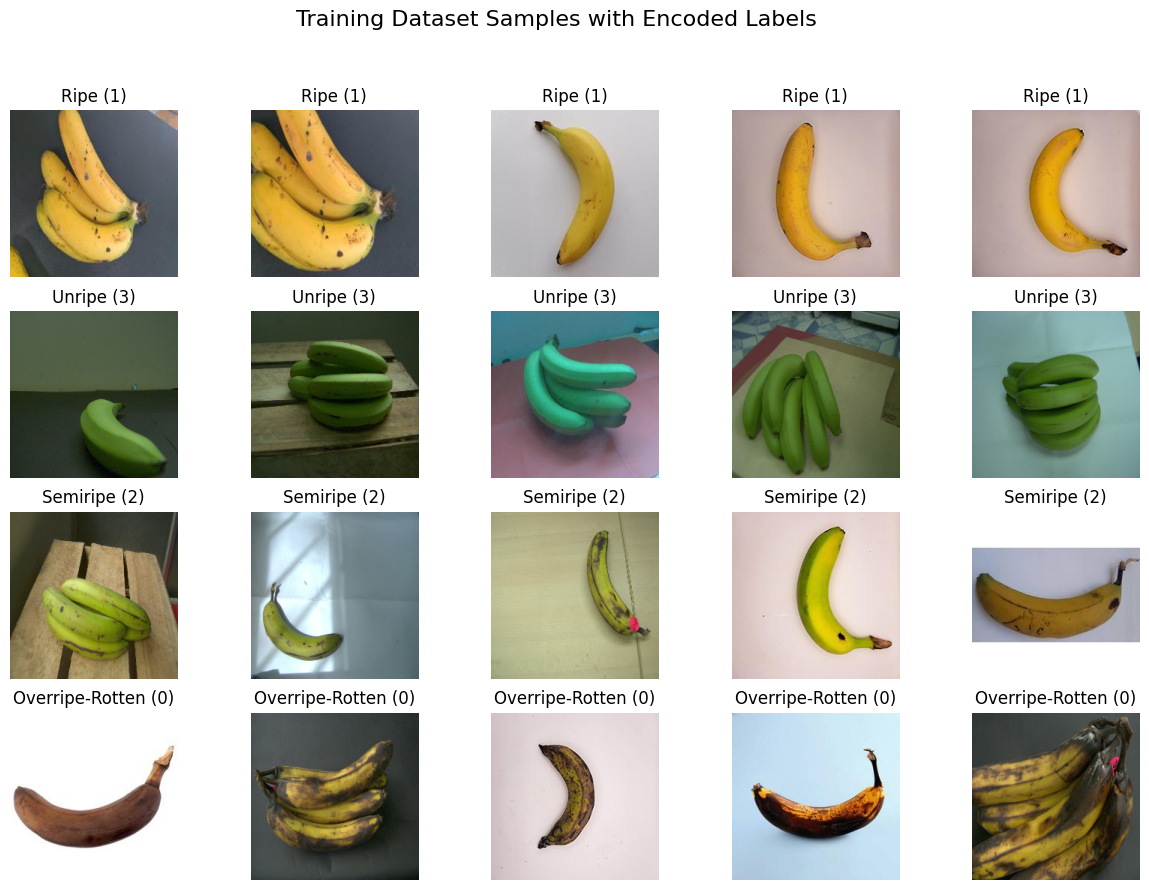

In [30]:
# ---- VISUALIZE 5 IMAGES FROM EACH CLASS (WITH ENCODED LABELS) ----
def visualize_class_samples(base_path, label_encoder, title="Sample Images from Each Class"):
    fig, axes = plt.subplots(len(categories), 5, figsize=(15, 10))

    for i, category in enumerate(categories):
        folder_path = os.path.join(base_path, category)
        if not os.path.exists(folder_path):
            continue

        # Get encoded label for this category
        encoded_label = label_encoder.transform([category])[0]

        images = random.sample(os.listdir(folder_path), min(5, len(os.listdir(folder_path))))

        for j, img_name in enumerate(images):
            img_path = os.path.join(folder_path, img_name)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Display the image with the original and encoded label
            axes[i, j].imshow(img)
            axes[i, j].axis("off")
            axes[i, j].set_title(f"{category} ({encoded_label})")

    plt.suptitle(title, fontsize=16)
    plt.show()

# Call the function with the label encoder
visualize_class_samples(dataset_path, label_encoder, "Training Dataset Samples with Encoded Labels")


In [12]:
# Split dataset (80% training, 20% testing)
X_train, X_test, y_train, y_test, img_train_paths, img_test_paths = train_test_split(
    data, encoded_labels, image_paths, test_size=0.2, random_state=42, stratify=encoded_labels)

In [13]:
# Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
# Train an SVM model (Linear Kernel for Classification)
print("\nTraining SVM Model...")
svm_model = SVC(kernel='linear', C=1.0, random_state=42)
svm_model.fit(X_train, y_train)


Training SVM Model...


SVC(kernel='linear', random_state=42)

In [15]:
# Save the trained model & scaler
model_save_path = "/content/drive/MyDrive/TCV BANANA/svm_EPnoPre.pkl"
scaler_save_path = "/content/drive/MyDrive/TCV BANANA/scalerEPnoPre.pkl"
joblib.dump(svm_model, model_save_path)
joblib.dump(scaler, scaler_save_path)
print(f"\nModel saved at: {model_save_path}")


Model saved at: /content/drive/MyDrive/TCV BANANA/svm_EPnoPre.pkl


In [16]:
# Predictions on test set
y_pred = svm_model.predict(X_test)

In [17]:
# Model Evaluation
print("\nClassification Report (Test Data):")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print(f"\nModel Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")


Classification Report (Test Data):
                 precision    recall  f1-score   support

Overripe-Rotten       0.87      0.89      0.88        70
           Ripe       0.96      0.93      0.94        70
       Semiripe       0.81      0.87      0.84        70
         Unripe       0.94      0.89      0.91        70

       accuracy                           0.89       280
      macro avg       0.90      0.89      0.89       280
   weighted avg       0.90      0.89      0.89       280


Confusion Matrix:
[[62  1  7  0]
 [ 4 65  0  1]
 [ 5  1 61  3]
 [ 0  1  7 62]]

Model Accuracy: 89.29%


In [19]:
# ---- VISUALIZE 5 RANDOM TEST IMAGES WITH PREDICTIONS ----
def visualize_predictions(image_paths, X_data, y_true, y_pred, title="Prediction Results"):
    num_samples = 5
    indices = random.sample(range(len(X_data)), num_samples)  # Randomly select test indices

    fig, axes = plt.subplots(1, num_samples, figsize=(15, 5))

    for i, idx in enumerate(indices):
        img_path = image_paths[idx]
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        true_label = label_encoder.inverse_transform([y_true[idx]])[0]
        predicted_label = label_encoder.inverse_transform([y_pred[idx]])[0]

        axes[i].imshow(img)
        axes[i].axis("off")
        axes[i].set_title(f"True: {true_label}\nPred: {predicted_label}")

    plt.suptitle(title, fontsize=14)
    plt.show()

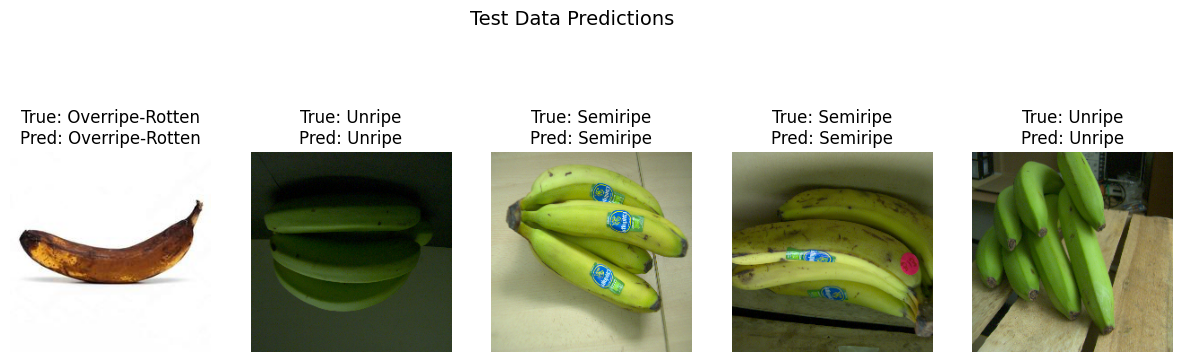

In [21]:
# Display random test images with their predictions
visualize_predictions(img_test_paths, X_test, y_test, y_pred, "Test Data Predictions")

In [22]:
# ---- TEST GENERALIZATION ON NEW DATASET ----
print("\nTesting on Own Dataset...")
own_data, own_labels, own_image_paths = load_dataset(own_dataset_path)


Testing on Own Dataset...


Loading Overripe-Rotten: 100%|██████████| 70/70 [00:22<00:00,  3.05it/s]


In [24]:
# Encode labels (Use same encoder)
own_encoded_labels = label_encoder.transform(own_labels)

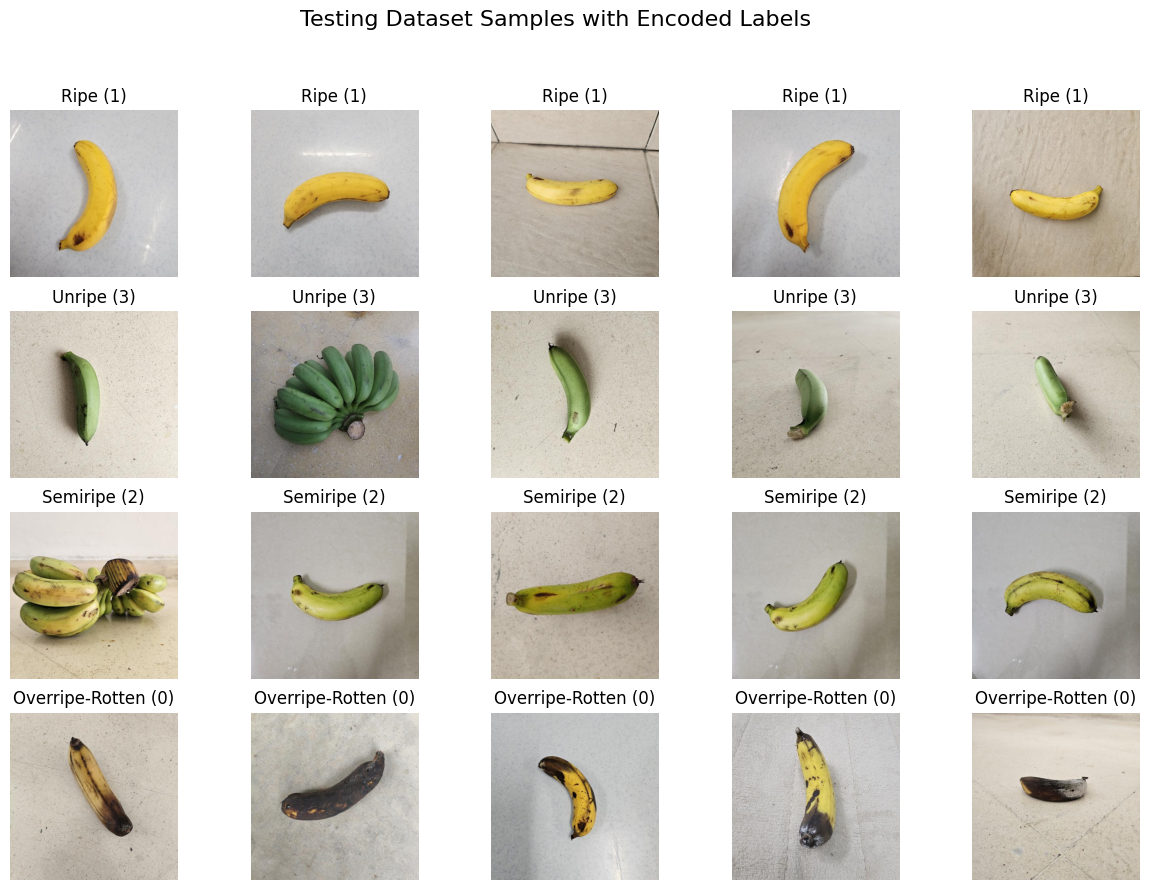

In [34]:
# Display sample images from each class (Training Data)
visualize_class_samples(own_dataset_path, label_encoder, "Testing Dataset Samples with Encoded Labels")

In [25]:
# Normalize features (Use same scaler)
own_data = scaler.transform(own_data)

In [26]:
# Load trained model (For Safety)
svm_model = joblib.load(model_save_path)

In [27]:
# Predictions on new dataset
own_pred = svm_model.predict(own_data)

In [28]:
# Model Evaluation on New Dataset
print("\nClassification Report (Own Dataset):")
print(classification_report(own_encoded_labels, own_pred, target_names=label_encoder.classes_))

print("\nConfusion Matrix (Own Dataset):")
print(confusion_matrix(own_encoded_labels, own_pred))

print(f"\nGeneralization Accuracy (Own Dataset): {accuracy_score(own_encoded_labels, own_pred) * 100:.2f}%")


Classification Report (Own Dataset):
                 precision    recall  f1-score   support

Overripe-Rotten       0.34      0.47      0.40        70
           Ripe       0.55      0.77      0.64        70
       Semiripe       0.42      0.16      0.23        70
         Unripe       0.55      0.47      0.51        70

       accuracy                           0.47       280
      macro avg       0.47      0.47      0.44       280
   weighted avg       0.47      0.47      0.44       280


Confusion Matrix (Own Dataset):
[[33 14  7 16]
 [10 54  2  4]
 [27 25 11  7]
 [26  5  6 33]]

Generalization Accuracy (Own Dataset): 46.79%


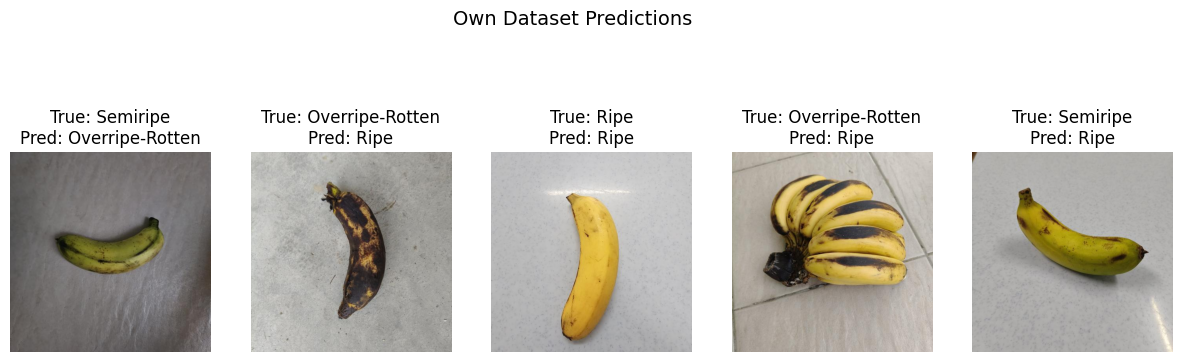

In [29]:
# Visualize random test images with their predictions (Own Dataset)
visualize_predictions(own_image_paths, own_data, own_encoded_labels, own_pred, "Own Dataset Predictions")